# SHAP Explainability

`06_model_comparison.ipynb` picked Random Forest as the model to deploy. This notebook explains *why* it flags a transaction as fraud -- which features push a prediction toward fraud vs. legitimate, and by how much, both globally and for individual transactions. Feature importance (in `02_random_forest.ipynb`) already ranked features by how much they're used; SHAP adds direction and per-prediction detail that raw importance can't.

## 1. Load Data & Model

In [1]:
import sys
sys.path.append('../src')
from data_prep import load_data
import numpy as np
import joblib

X_train, X_test, y_train, y_test, amount_test = load_data()
rf_model = joblib.load('../models/rf.pkl')

## 2. Compute SHAP Values

Computing exact SHAP values for all 56,962 test rows is unnecessary and slow for a summary plot. Sample instead: every fraud case (only 98, and they're what we actually care about explaining), every false positive at the cost-optimal threshold (guaranteed, not left to random luck -- there are only 14, easy to miss in a random sample), plus a random sample of legitimate transactions for contrast.

In [2]:
import shap
import json

with open('../models/rf_thresholds.json') as f:
    rf_meta = json.load(f)
cost_threshold = rf_meta['cost_optimal_threshold']

rf_probs_full = rf_model.predict_proba(X_test)[:, 1]
y_pred_full = (rf_probs_full >= cost_threshold).astype(int)
y_test_arr_full = y_test.values

fraud_idx = np.where(y_test_arr_full == 1)[0]
fp_idx = np.where((y_pred_full == 1) & (y_test_arr_full == 0))[0]

rng = np.random.RandomState(42)
legit_idx = np.where(y_test_arr_full == 0)[0]
legit_idx_available = np.setdiff1d(legit_idx, fp_idx)
legit_sample_idx = rng.choice(legit_idx_available, size=1000, replace=False)

sample_idx = np.concatenate([fraud_idx, fp_idx, legit_sample_idx])
X_sample = X_test.iloc[sample_idx]
y_sample = y_test.iloc[sample_idx]

print(f"Sample: {len(fraud_idx)} fraud, {len(fp_idx)} false positives, {len(legit_sample_idx)} random legit")

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_sample)

# shap_values is (n_samples, n_features, n_classes) for this sklearn/shap version -- take the fraud class
if isinstance(shap_values, list):
    shap_values_fraud = shap_values[1]
elif shap_values.ndim == 3:
    shap_values_fraud = shap_values[:, :, 1]
else:
    shap_values_fraud = shap_values

print("SHAP values shape:", shap_values_fraud.shape)

c:\Users\Owner\Documents\Programming\AIML\AIML_FraudDetection\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Sample: 98 fraud, 14 false positives, 1000 random legit
SHAP values shape: (1112, 30)


## 3. Global Feature Importance (SHAP Summary)

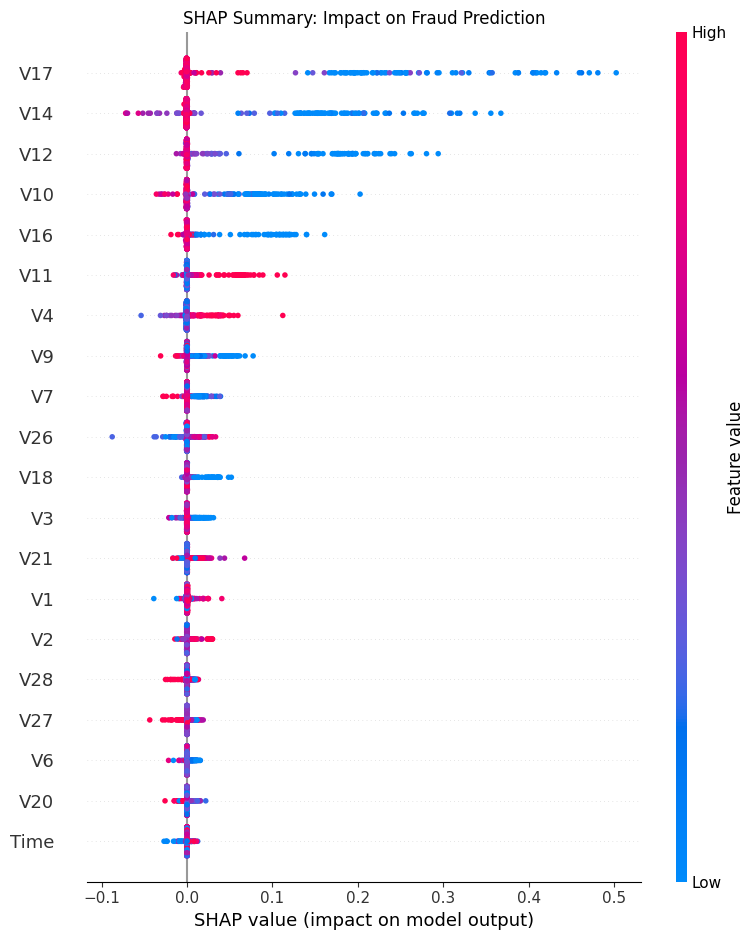

In [3]:
import matplotlib.pyplot as plt

shap.summary_plot(shap_values_fraud, X_sample, show=False)
plt.title("SHAP Summary: Impact on Fraud Prediction")
plt.tight_layout()
plt.show()

The axes and elements:

### -Row (top to bottom) = one feature, ordered by overall importance (same ranking as the built-in feature_importances_ — most impactful at top).
### -Each dot = one actual transaction from your sample.
### -Horizontal position (x-axis) = how much that feature's value pushed that specific transaction's prediction toward fraud (right, positive) or toward legitimate (left, negative). This is the model's actual fraud-probability push, not just "importance."
### -Color = the feature's actual value for that transaction — pink/red = high value, blue = low value (see the color bar).

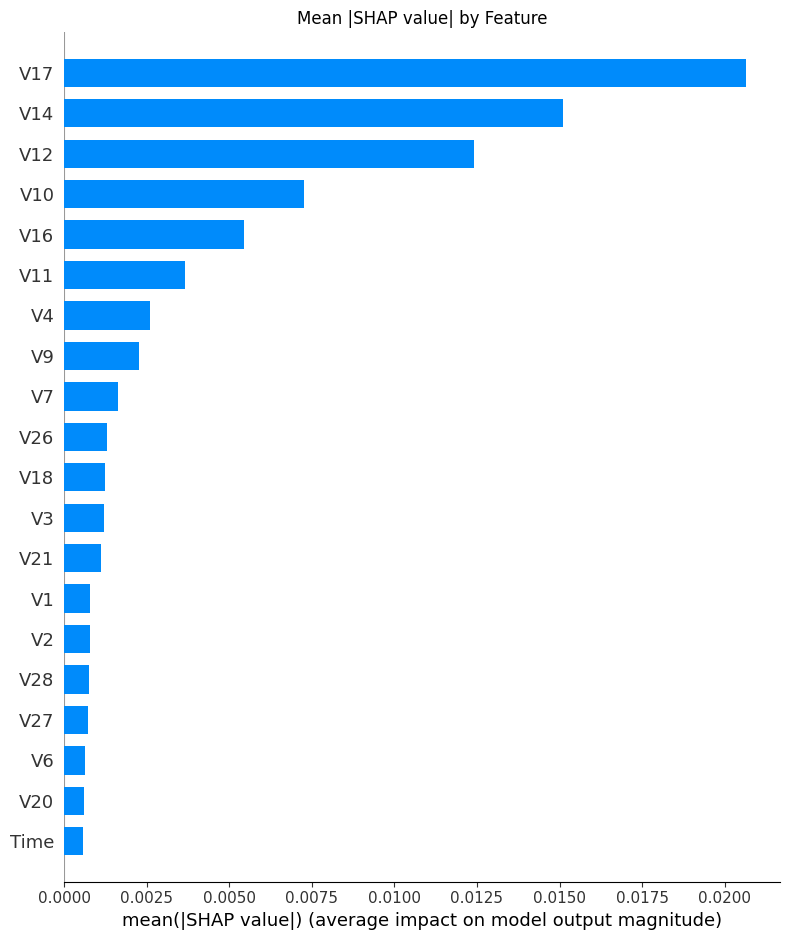

In [4]:
shap.summary_plot(shap_values_fraud, X_sample, plot_type="bar", show=False)
plt.title("Mean |SHAP value| by Feature")
plt.tight_layout()
plt.show()

## 4. SHAP Importance vs. Built-in Feature Importance

`02_random_forest.ipynb`'s built-in `feature_importances_` ranked `V17`, `V14`, `V12`, `V10`, `V16` as the top five by how often they're used to split. Compare that to SHAP's ranking by actual impact on individual predictions -- do the same features come out on top?

In [5]:
import pandas as pd

mean_abs_shap = np.abs(shap_values_fraud).mean(axis=0)
shap_importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean |SHAP|': mean_abs_shap
}).sort_values(by='Mean |SHAP|', ascending=False)

print(shap_importance_df.head(10))

   Feature  Mean |SHAP|
17     V17     0.020642
14     V14     0.015096
12     V12     0.012412
10     V10     0.007262
16     V16     0.005459
11     V11     0.003652
4       V4     0.002598
9       V9     0.002273
7       V7     0.001624
26     V26     0.001301


## 5. Explain Individual Predictions

Three specific cases, using the cost-optimal threshold from `02_random_forest.ipynb`: a confidently-caught fraud, a missed fraud (false negative), and a false alarm (false positive). Each waterfall plot shows exactly which features pushed that one prediction toward fraud or away from it.

In [6]:
rf_probs_sample = rf_model.predict_proba(X_sample)[:, 1]
y_pred_sample = (rf_probs_sample >= cost_threshold).astype(int)
y_sample_arr = y_sample.values

tp_mask = (y_pred_sample == 1) & (y_sample_arr == 1)
fn_mask = (y_pred_sample == 0) & (y_sample_arr == 1)
fp_mask = (y_pred_sample == 1) & (y_sample_arr == 0)

print(f"True positives in sample: {tp_mask.sum()}, False negatives: {fn_mask.sum()}, False positives: {fp_mask.sum()}")

# Most confident true positive
tp_candidates = np.where(tp_mask)[0]
best_tp = tp_candidates[np.argmax(rf_probs_sample[tp_candidates])]

# A false negative, if any exist in the sample
fn_candidates = np.where(fn_mask)[0]
example_fn = fn_candidates[0] if len(fn_candidates) > 0 else None

# The false positive the model was most confident about
fp_candidates = np.where(fp_mask)[0]
example_fp = fp_candidates[np.argmax(rf_probs_sample[fp_candidates])] if len(fp_candidates) > 0 else None

True positives in sample: 86, False negatives: 12, False positives: 14


Confidently caught fraud (probability=1.0000):


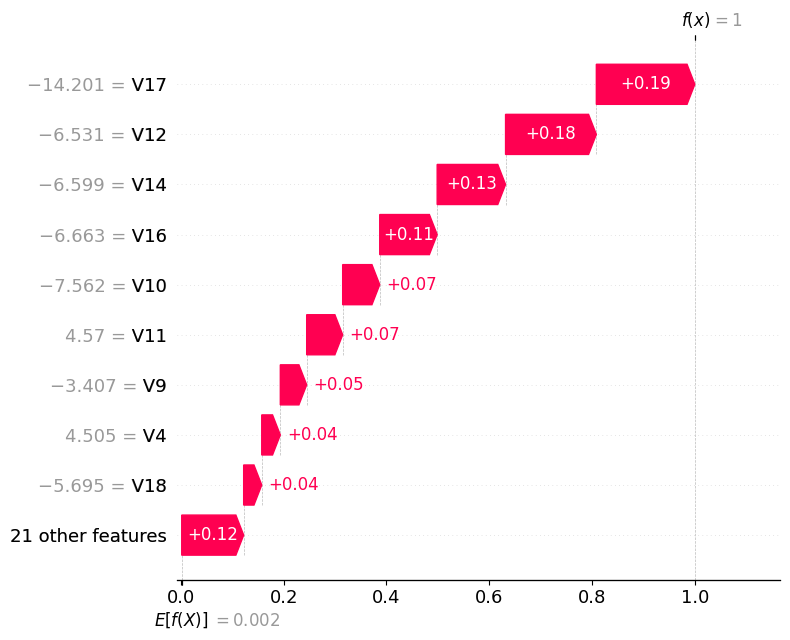

In [7]:
explanation = shap.Explanation(
    values=shap_values_fraud,
    base_values=np.full(len(X_sample), explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value),
    data=X_sample.values,
    feature_names=X_sample.columns.tolist()
)

print(f"Confidently caught fraud (probability={rf_probs_sample[best_tp]:.4f}):")
shap.plots.waterfall(explanation[best_tp], show=False)
plt.tight_layout()
plt.show()

#### How to read it:

### -Bottom-left, E[f(X)] = 0.002 — this is the baseline: if you knew nothing about this specific transaction, the model's average predicted fraud probability (across the whole dataset) is 0.2% — matching the real ~0.17% fraud rate. Every prediction starts here.
### -Each bar = one feature, showing how much this transaction's specific value for that feature pushed the prediction up from the baseline. The number on the left (e.g., -14.201 = V17) is this transaction's actual value for that feature.
### -The bars stack cumulatively, left to right, climbing from 0.002 up to the final prediction at the top right: f(x) = 1 — the model ended up ~100% confident this is fraud.
### -"21 other features" (+0.12) — all the remaining, individually-small features lumped together, since listing all 30 would be unreadable.

### The numbers tell a striking story: remember your features are all standard-scaled, meaning each value is literally a "number of standard deviations from normal." A value like V17 = -14.201 isn't just "low" — it's 14 standard deviations away from the average transaction, an almost unimaginably extreme outlier (for comparison, 3 standard deviations already covers ~99.7% of normal data). V12 = -6.531, V14 = -6.599, V16 = -6.663, V10 = -7.562 are similarly extreme. That's why the model is so confident — this transaction isn't borderline at all, it's wildly abnormal on five of its most important features simultaneously.

### This directly confirms what you saw in the beeswarm plot: V17, V12, V14, V16, V10 all have low/negative values here and are all pushing toward fraud (positive SHAP) — exactly the "low value → fraud" pattern those features showed across the whole dataset. And V11 = 4.57 (a high value) is also pushing toward fraud (+0.07) — matching the one feature that flipped direction in the beeswarm plot. This one transaction is a concrete, real example of the general patterns you already identified.

Missed fraud (probability=0.0000, below threshold 0.3000):


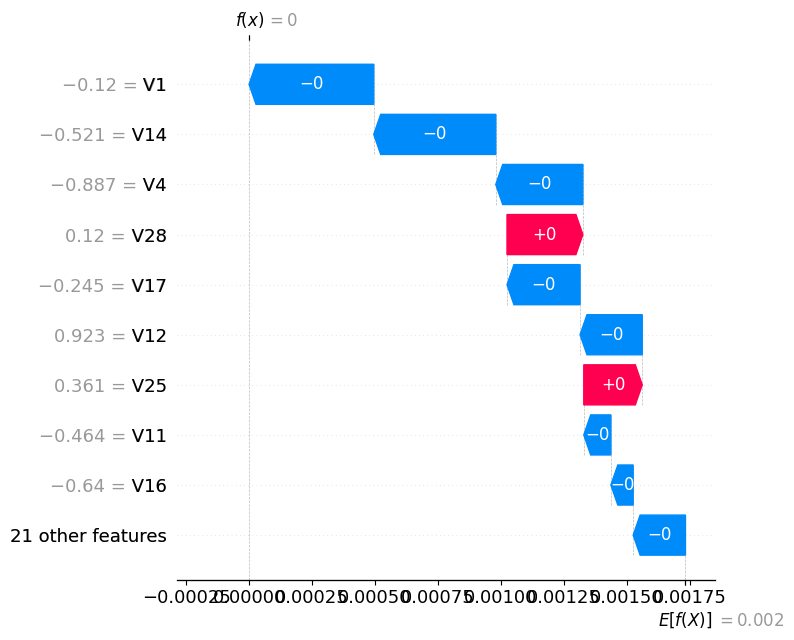

In [8]:
if example_fn is not None:
    print(f"Missed fraud (probability={rf_probs_sample[example_fn]:.4f}, below threshold {cost_threshold:.4f}):")
    shap.plots.waterfall(explanation[example_fn], show=False)
    plt.tight_layout()
    plt.show()
else:
    print("No false negatives in this sample.")

False alarm (probability=0.9800, above threshold 0.3000):


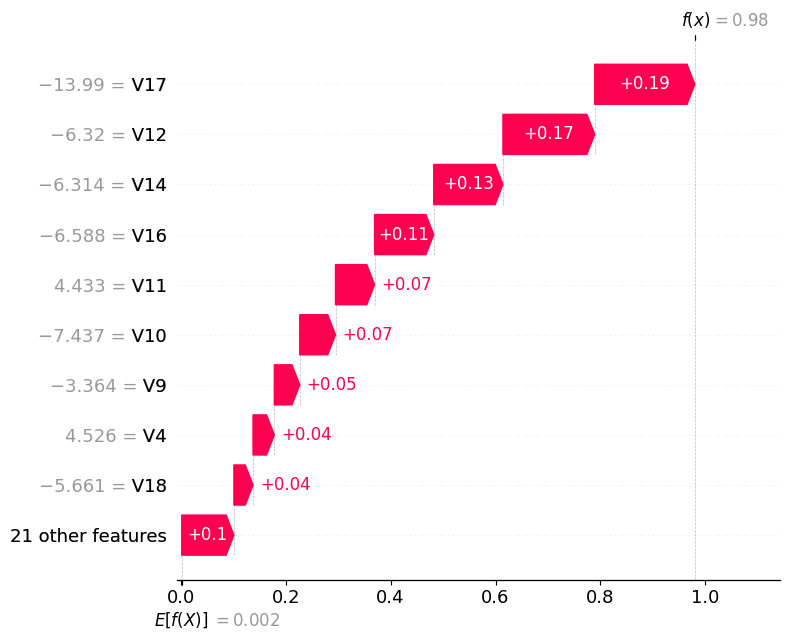

In [9]:
if example_fp is not None:
    print(f"False alarm (probability={rf_probs_sample[example_fp]:.4f}, above threshold {cost_threshold:.4f}):")
    shap.plots.waterfall(explanation[example_fp], show=False)
    plt.tight_layout()
    plt.show()
else:
    print("No false positives in this sample.")

## 6. Conclusion

The features SHAP identifies as most impactful should line up with three independent signals already found earlier in this project: `02_random_forest.ipynb`'s built-in feature importance, `03_xgboost_tuned.ipynb`'s feature importance, and the statistically significant coefficients from the logistic regression check in `01_eda_preprocessing.ipynb`. Agreement across four different methods (two feature-importance rankings, one statistical significance test, and SHAP) is a strong signal that a handful of PCA components genuinely carry the fraud signal in this dataset, rather than the model latching onto noise.

Beyond confirming *which* features matter, the individual waterfall plots show *why* a specific transaction was flagged or missed -- the kind of explanation an actual fraud review team would need to trust and act on a model's decision, not just a probability score.